# QAOA circuit to TN


Searching for Greedy path...


F=5.87 C=7.21 S=14.00 P=15.02: 100%|██████████| 1/1 [00:00<00:00, 88.14it/s]


Searching for Optimized path...


F=4.74 C=5.67 S=10.00 P=11.17: 100%|██████████| 32/32 [00:00<00:00, 164.89it/s]


------------------------------
Greedy Cost (log10):    5.87
Optimized Cost (log10): 4.74
------------------------------


<Figure size 600x600 with 0 Axes>

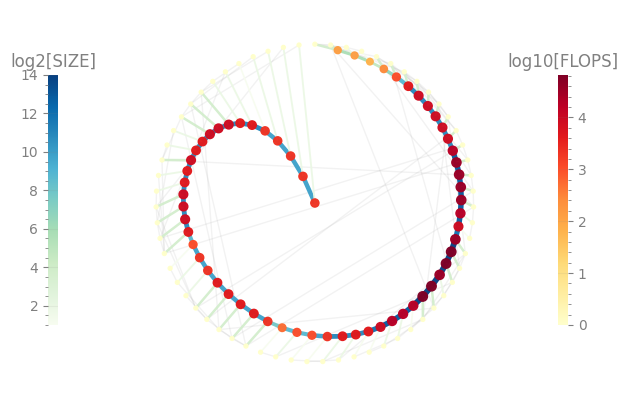

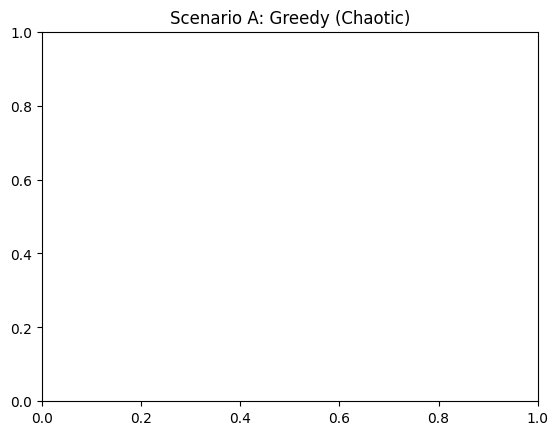

<Figure size 600x600 with 0 Axes>

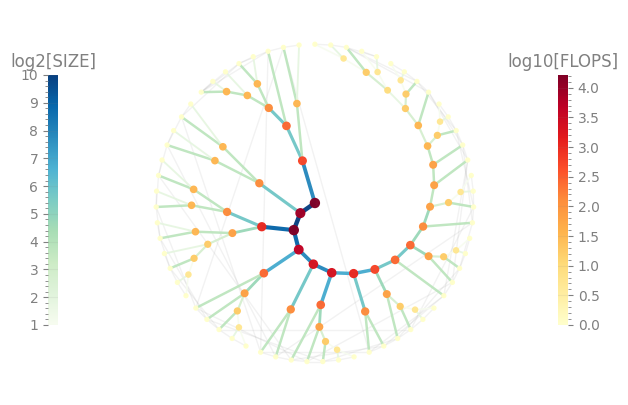

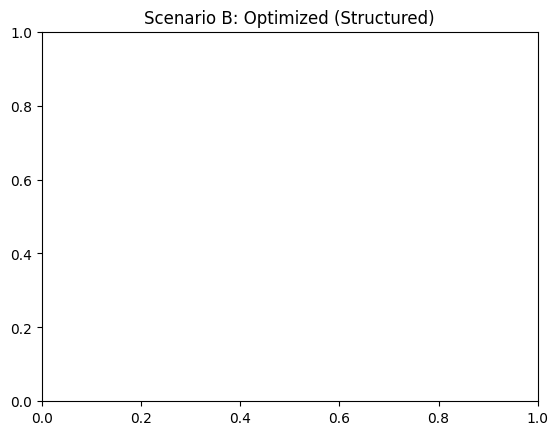

<Figure size 800x500 with 0 Axes>

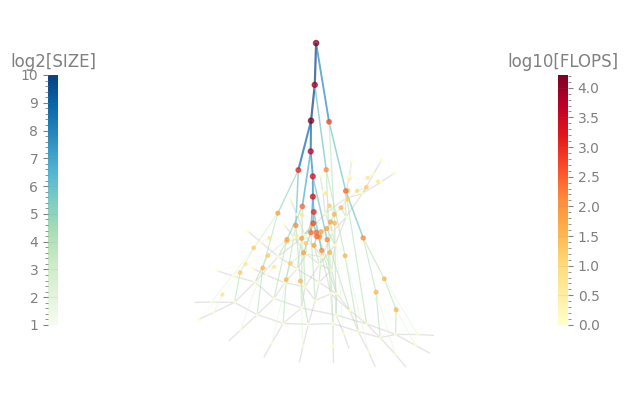

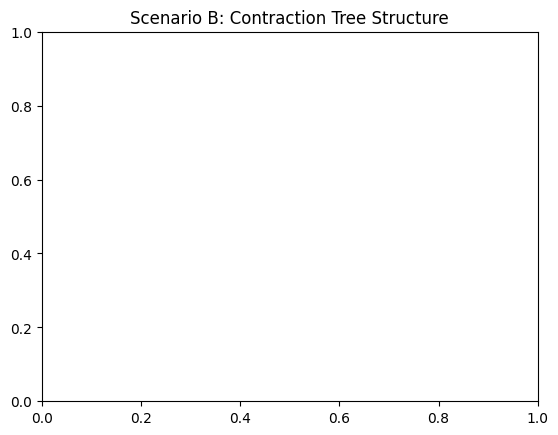

In [31]:
import quimb.tensor as qtn
import networkx as nx
import matplotlib.pyplot as plt
import cotengra as ctg
import math  # REQUIRED for log10

# 1. Setup the QAOA Tensor Network
G = nx.erdos_renyi_graph(n=10, p=0.7, seed=42)
terms = {edge: 1.0 for edge in G.edges}
circ = qtn.circ_qaoa(terms, depth=1, gammas=[0.1], betas=[0.2])
tn = circ.psi

# ---------------------------------------------------------
# Define Optimizers
# ---------------------------------------------------------

# Scenario A: Greedy
opt_greedy = ctg.HyperOptimizer(
    methods=['greedy'], 
    max_repeats=1, 
    progbar=True
)

# Scenario B: Optimized (Auto)
# We remove 'methods' so it auto-selects valid solvers for Windows
opt_hq = ctg.HyperOptimizer(
    max_repeats=32, 
    progbar=True
)

# ---------------------------------------------------------
# Search for Paths
# ---------------------------------------------------------
inputs = [tuple(t.inds) for t in tn]
output = tuple(tn.outer_inds()) 
size_dict = {i: d for i, d in tn.ind_sizes().items()}

print("Searching for Greedy path...")
tree_greedy = opt_greedy.search(inputs, output, size_dict)

print("Searching for Optimized path...")
tree_hq = opt_hq.search(inputs, output, size_dict)

# ---------------------------------------------------------
# VISUALIZATION (CORRECTED)
# ---------------------------------------------------------
print("-" * 30)
# FIX 1: Use math.log10()
print(f"Greedy Cost (log10):    {math.log10(tree_greedy.total_flops()):.2f}")
print(f"Optimized Cost (log10): {math.log10(tree_hq.total_flops()):.2f}")
print("-" * 30)

# FIX 2: Standard Matplotlib pattern
# Create figure -> Plot -> Set Title -> Show

# Plot 1: Greedy Ring
plt.figure(figsize=(6, 6))           # Create generic figure
tree_greedy.plot_ring()              # Plot to active figure
plt.title("Scenario A: Greedy (Chaotic)") # Set title manually
plt.show()

# Plot 2: Optimized Ring
plt.figure(figsize=(6, 6))
tree_hq.plot_ring()
plt.title("Scenario B: Optimized (Structured)")
plt.show()

# Plot 3: Optimized Tent
plt.figure(figsize=(8, 5))
tree_hq.plot_tent()
plt.title("Scenario B: Contraction Tree Structure")
plt.show()

--- Qiskit Circuit: Linear Graph (Sparse) ---


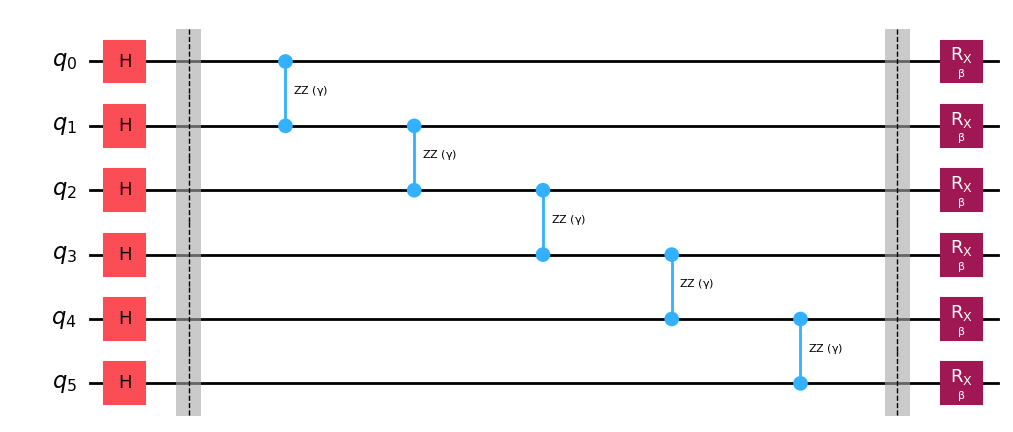

<Figure size 600x600 with 0 Axes>

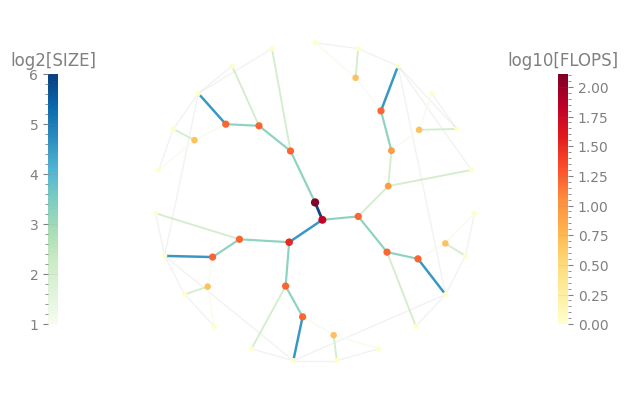

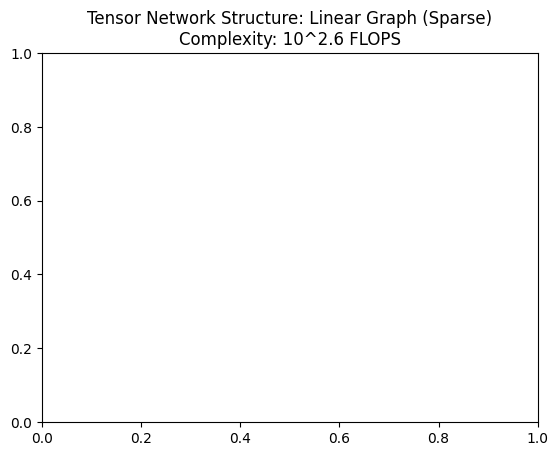

--- Qiskit Circuit: Complete Graph (Dense) ---


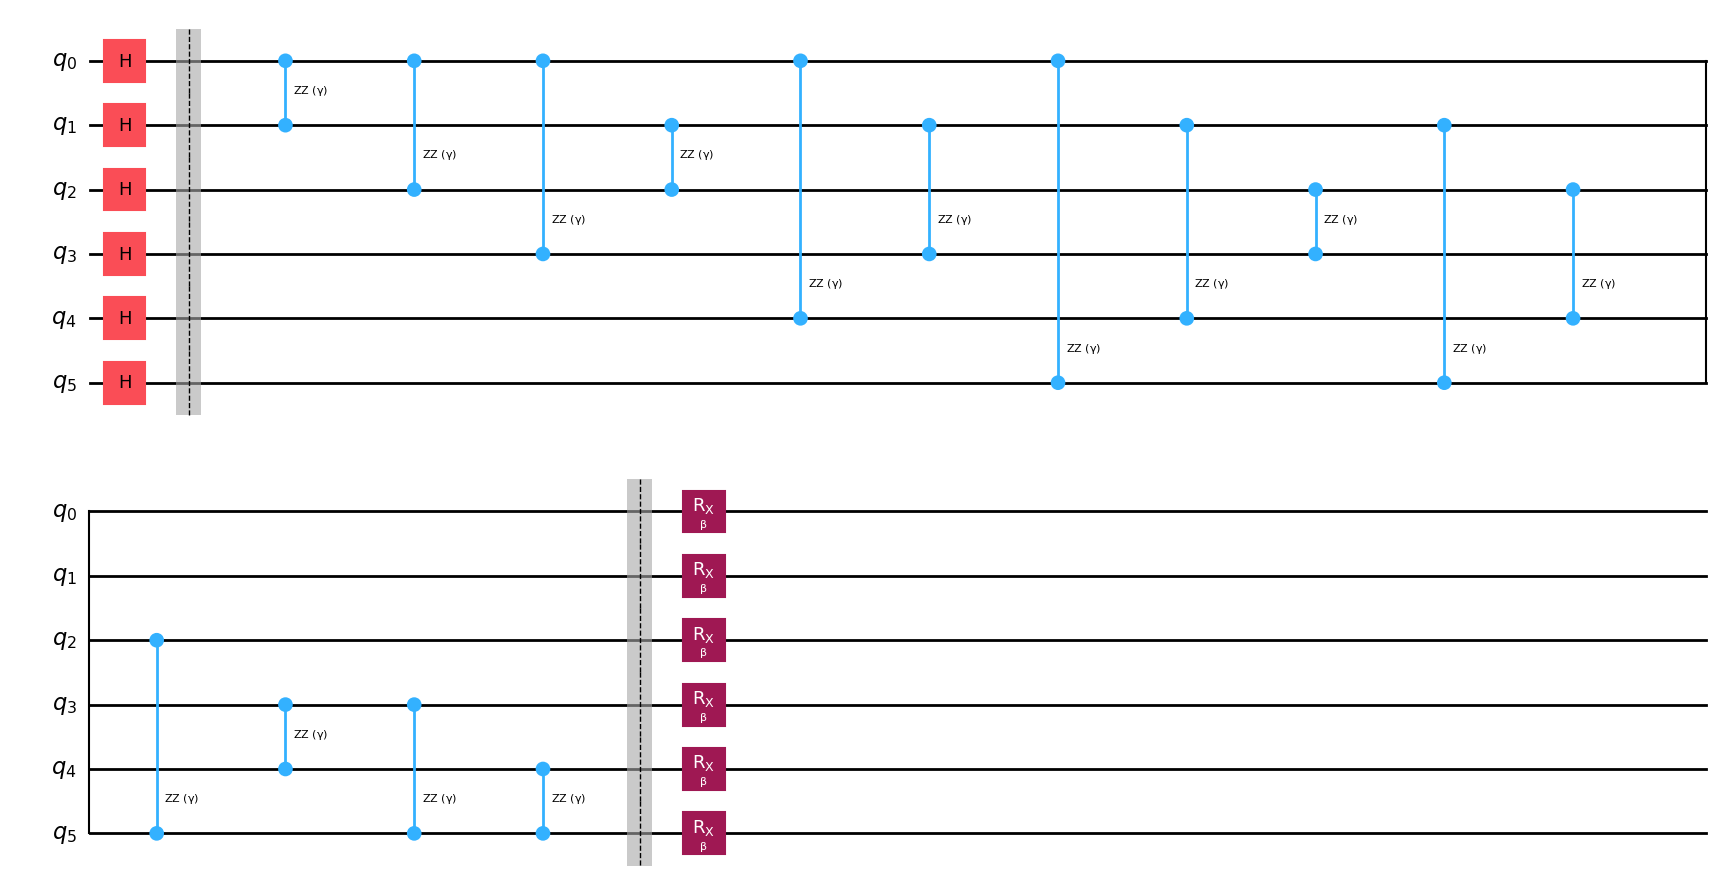

<Figure size 600x600 with 0 Axes>

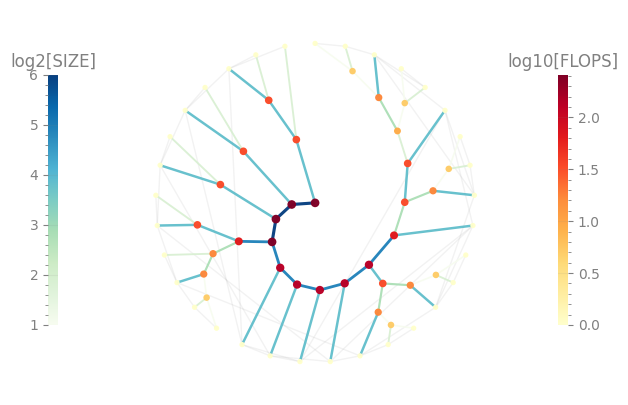

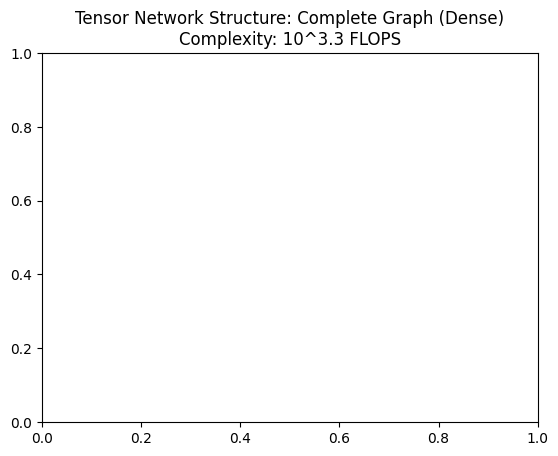

In [35]:
import networkx as nx
import matplotlib.pyplot as plt
import math

# Tool 1: Qiskit (For the pretty Circuit Diagram)
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

# Tool 2: Quimb/Cotengra (For the Tensor Network Analysis)
import quimb.tensor as qtn
import cotengra as ctg

def draw_qaoa_qiskit(G, name):
    """Draws a professional QAOA circuit using Qiskit"""
    n = len(G.nodes)
    qc = QuantumCircuit(n)
    
    # 1. Initial State (Hadamards)
    qc.h(range(n))
    qc.barrier()
    
    # 2. Cost Hamiltonian (Phase Separation)
    # Apply RZZ gates for every edge in the graph
    gamma = Parameter('γ')
    for u, v in G.edges:
        qc.rzz(gamma, u, v)
    qc.barrier()
    
    # 3. Mixer Hamiltonian
    # Apply RX gates for every node
    beta = Parameter('β')
    qc.rx(beta, range(n))
    
    # Draw it
    print(f"--- Qiskit Circuit: {name} ---")
    # 'mpl' uses Matplotlib to render a high-res image
    display(qc.draw('mpl', style='iqp')) 

def analyze_tn_structure(G, name):
    """Analyzes the Tensor Network structure using Quimb"""
    
    # Convert Graph to Quimb Circuit
    terms = {edge: 1.0 for edge in G.edges}
    circ = qtn.circ_qaoa(terms, depth=1, gammas=[0.1], betas=[0.2])
    tn = circ.psi
    
    # Find the contraction path (using robust 'auto' mode)
    opt = ctg.HyperOptimizer(max_repeats=16, progbar=False)
    inputs = [tuple(t.inds) for t in tn]
    output = tuple(tn.outer_inds()) 
    size_dict = {i: d for i, d in tn.ind_sizes().items()}
    
    tree = opt.search(inputs, output, size_dict)
    cost = math.log10(tree.total_flops())
    
    # Plot the Ring View
    plt.figure(figsize=(6, 6))
    tree.plot_ring()
    plt.title(f"Tensor Network Structure: {name}\nComplexity: 10^{cost:.1f} FLOPS")
    plt.show()

# ==========================================
# MASTER RUNNER
# ==========================================

def run_comparison(G, name):
    # 1. Draw the Circuit (Qiskit)
    draw_qaoa_qiskit(G, name)
    
    # 2. Visualize the Math (Quimb)
    analyze_tn_structure(G, name)

# --- CASE 1: Linear Graph (Nearest Neighbor) ---
# This is physically easy to build (qubits next to each other)
G_line = nx.path_graph(6) 
run_comparison(G_line, "Linear Graph (Sparse)")

# --- CASE 2: Complete Graph (All-to-All) ---
# This is physically hard (requires swapping or long-range gates)
G_dense = nx.complete_graph(6)
run_comparison(G_dense, "Complete Graph (Dense)")

### Below the slicing is added

RAM Limit (MB)  | Slices     | Overhead   | Max Ten. Size
-----------------------------------------------------------------
64              | 1          | 1.00      x | 2^22.0
32              | 1          | 1.00      x | 2^21.0
16              | 1          | 1.00      x | 2^20.0
8               | 1          | 1.00      x | 2^19.0
4               | 1          | 1.00      x | 2^18.0
2               | 1          | 1.00      x | 2^17.0
1               | 1          | 1.00      x | 2^16.0
0.5             | 1          | 1.00      x | 2^15.0


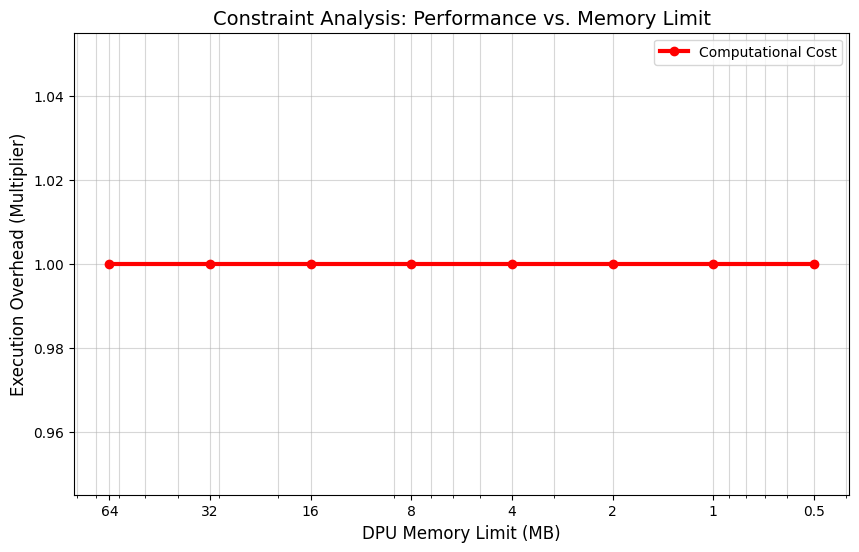

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import math
import cotengra as ctg
import networkx as nx
import quimb.tensor as qtn

# (Re-defining this helper just in case)
def get_qaoa_tn(n_qubits=14):
    G = nx.complete_graph(n_qubits)
    terms = {edge: 1.0 for edge in G.edges}
    circ = qtn.circ_qaoa(terms, depth=1, gammas=[0.1], betas=[0.2])
    return circ.psi

def analyze_memory_tradeoff(tn, limits_mb):
    """
    Sweeps through different RAM limits to see how 'Slicing Overhead' increases.
    """
    results = []
    
    print(f"{'RAM Limit (MB)':<15} | {'Slices':<10} | {'Overhead':<10} | {'Max Ten. Size'}")
    print("-" * 65)

    for limit_mb in limits_mb:
        # 1. Convert MB to Bytes/Log2
        limit_bytes = limit_mb * 1024 * 1024
        # complex128 = 16 bytes. Log2 of elements:
        target_log2 = math.log2(limit_bytes / 16)
        
        # 2. Run the Slicing Optimizer
        # --- FIX: Removed "methods=['auto']" ---
        opt = ctg.HyperOptimizer(
            max_repeats=8,   # Fewer repeats for speed in this loop
            progbar=False,   # Turn off progress bar to keep output clean
            slicing_opts={
                'target_size': 2**target_log2,
                'target_slices': None
            }
        )
        
        # Extract structure
        inputs = [tuple(t.inds) for t in tn]
        output = tuple(tn.outer_inds())
        size_dict = {i: d for i, d in tn.ind_sizes().items()}
        
        # Search
        try:
            tree = opt.search(inputs, output, size_dict)
            
            # 3. Collect Data
            flops_original = tree.contract_stats()['flops']
            flops_sliced = tree.total_flops()
            
            # Overhead = (Work done with slicing) / (Work done if we had infinite RAM)
            overhead = flops_sliced / flops_original
            num_slices = tree.nslices
            
            # Record metrics
            results.append({
                "RAM_MB": limit_mb,
                "Overhead": overhead,
                "Slices": num_slices,
                "Log2_Size": target_log2
            })
            
            print(f"{limit_mb:<15} | {num_slices:<10} | {overhead:<10.2f}x | 2^{target_log2:.1f}")
            
        except Exception as e:
            # If a limit is IMPOSSIBLE to hit (e.g. smaller than a single number), it fails gracefully
            print(f"{limit_mb:<15} | FAILED ({str(e)})")

    return pd.DataFrame(results)

# ==========================================
# RUN THE EXPERIMENT
# ==========================================

# 1. Setup the Problem (Dense QAOA)
# 14 qubits is a good balance for a laptop test
tn_experiment = get_qaoa_tn(n_qubits=14)

# 2. Define the Limits to Test
# We go from "Plenty of RAM" (64MB) down to "Tiny RAM" (0.5MB)
limits_to_test = [64, 32, 16, 8, 4, 2, 1, 0.5]

# 3. Run Analysis
df = analyze_memory_tradeoff(tn_experiment, limits_to_test)

# ==========================================
# VISUALIZE THE RESULTS
# ==========================================

plt.figure(figsize=(10, 6))

# Plot Overhead vs RAM
plt.plot(df["RAM_MB"], df["Overhead"], marker='o', linewidth=3, color='red', label='Computational Cost')

plt.title("Constraint Analysis: Performance vs. Memory Limit", fontsize=14)
plt.xlabel("DPU Memory Limit (MB)", fontsize=12)
plt.ylabel("Execution Overhead (Multiplier)", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()

# 1. Invert X axis (Convention: Limits get tighter as we go right)
plt.gca().invert_xaxis() 

# 2. Log scale helps visualize the orders of magnitude changes
plt.xscale('log') 
plt.xticks(limits_to_test, labels=[str(x) for x in limits_to_test])

plt.show()


STEP 1: THE CIRCUIT (Logical View)
Creating a dense QAOA circuit with 18 qubits...
Explanation: Horizontal lines are qubits. Vertical blocks are gates.
In a dense QAOA, every qubit interacts with every other qubit.
(Displaying text representation for clarity...)
<Circuit(n=18, num_gates=189, gate_opts={'contract': False, 'propagate_tags': 'register'})>

STEP 2: THE TENSOR NETWORK (Mathematical View)
Nodes (Tensors): 207
Edges (Indices): 360
Explanation: Every 'Gate' from Step 1 became a 'Node' here.
The lines connecting them represent the quantum entanglement.
Notice the 'Spiderweb' structure? That's because it's a Complete Graph.


<Figure size 800x800 with 0 Axes>

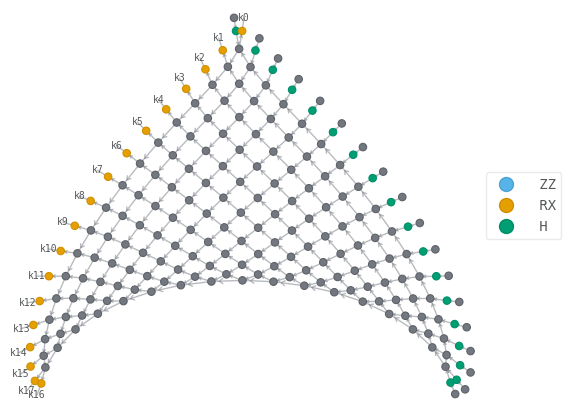

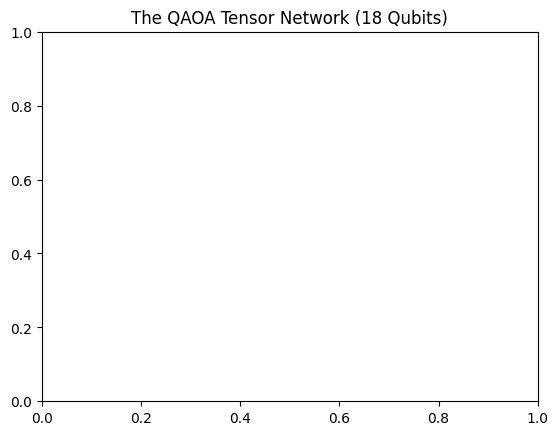


STEP 3: NAIVE CONTRACTION PATH
Simulating a standard optimizer (Greedy)...
Max Intermediate Tensor: 2^36.0 elements
Explanation: Look at the center of the ring plot.
The messy crossing lines mean we are keeping MANY tensors in memory at once.
This causes RAM explosion.


<Figure size 600x600 with 0 Axes>

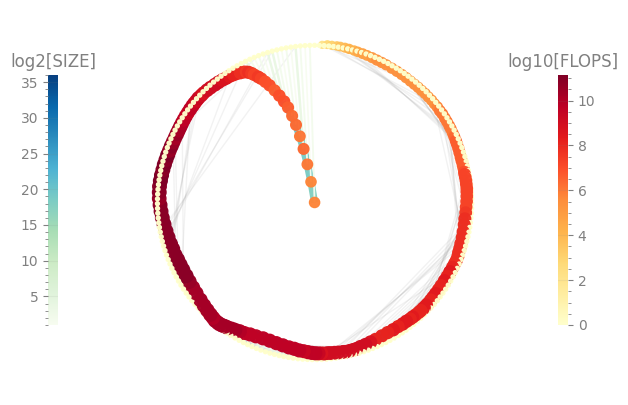

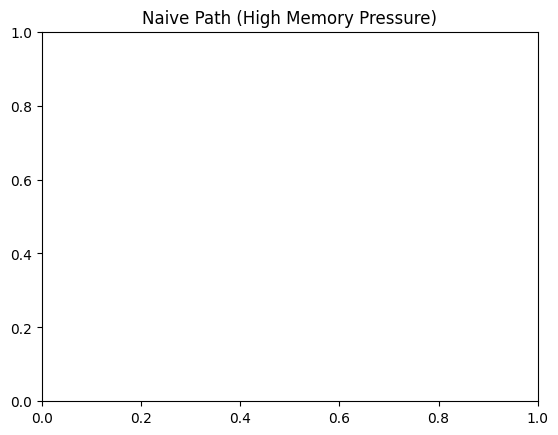


STEP 4: UPMEM-OPTIMIZED PATH (Slicing)
Constraint: Fit everything into 1.0 MB (2^16.0 elements)
Optimizing...


F=8.69 C=9.07 S=16.00 P=17.18 $=16.00: 100%|██████████| 16/16 [01:25<00:00,  5.34s/it] 


Number of Slices (Parallel Tasks): 16
Slicing Overhead: 1.00x
Explanation: Look at the Dashed Lines/Colored Edges.
These are the 'Cuts'. We cut these wires to separate the web into
smaller, independent chunks that fit on the UPMEM DPU.


<Figure size 600x600 with 0 Axes>

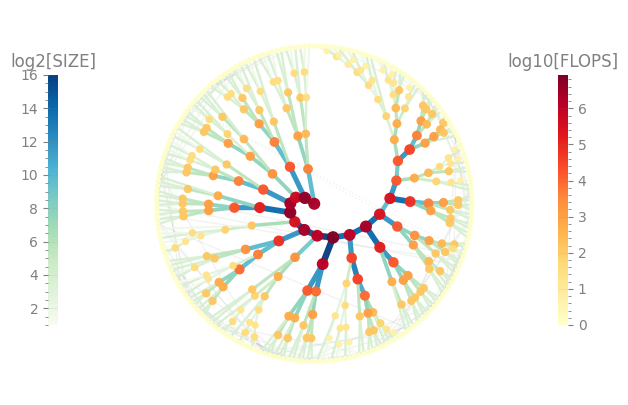

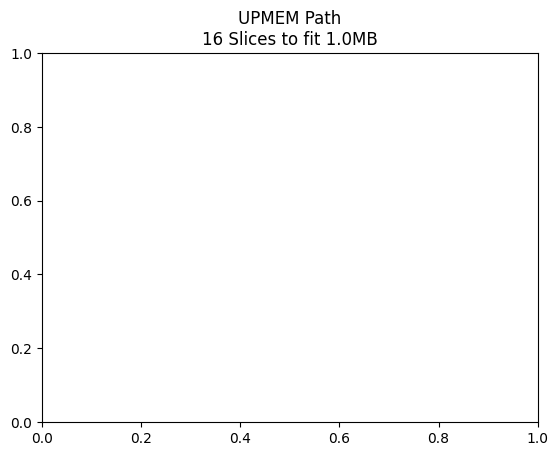

In [40]:
import quimb.tensor as qtn
import networkx as nx
import matplotlib.pyplot as plt
import cotengra as ctg
import math

# ==========================================
# CONFIGURATION
# ==========================================
# We use 18 qubits to force the memory size to ~4MB
# If we set the limit to 1MB, the optimizer MUST slice.
N_QUBITS = 18 
MEMORY_LIMIT_MB = 1.0  # Force it to fit into 1MB (UPMEM Simulation)

# ==========================================
# 1. VISUALIZE THE CIRCUIT
# ==========================================
def step_1_circuit():
    print("\n" + "="*50)
    print("STEP 1: THE CIRCUIT (Logical View)")
    print("="*50)
    print(f"Creating a dense QAOA circuit with {N_QUBITS} qubits...")
    
    # Create Graph
    G = nx.complete_graph(N_QUBITS)
    terms = {edge: 1.0 for edge in G.edges}
    
    # Create Circuit
    circ = qtn.circ_qaoa(terms, depth=1, gammas=[0.1], betas=[0.2])
    
    print("Explanation: Horizontal lines are qubits. Vertical blocks are gates.")
    print("In a dense QAOA, every qubit interacts with every other qubit.")
    print("(Displaying text representation for clarity...)")
    print(circ) 
    
    return circ

# ==========================================
# 2. VISUALIZE THE TENSOR NETWORK
# ==========================================
def step_2_tensor_network(circ):
    print("\n" + "="*50)
    print("STEP 2: THE TENSOR NETWORK (Mathematical View)")
    print("="*50)
    
    tn = circ.psi
    
    print(f"Nodes (Tensors): {tn.num_tensors}")
    print(f"Edges (Indices): {tn.num_indices}")
    print("Explanation: Every 'Gate' from Step 1 became a 'Node' here.")
    print("The lines connecting them represent the quantum entanglement.")
    print("Notice the 'Spiderweb' structure? That's because it's a Complete Graph.")
    
    plt.figure(figsize=(8, 8))
    # 'color' helps distinguish layers of the QAOA
    tn.draw(color=['ZZ', 'RX', 'H'], show_tags=False) 
    plt.title(f"The QAOA Tensor Network ({N_QUBITS} Qubits)")
    plt.show()
    
    return tn

# ==========================================
# 3. NAIVE PATH (The "Bad" Approach)
# ==========================================
def step_3_naive_path(tn):
    print("\n" + "="*50)
    print("STEP 3: NAIVE CONTRACTION PATH")
    print("="*50)
    print("Simulating a standard optimizer (Greedy)...")
    
    opt = ctg.HyperOptimizer(methods=['greedy'], max_repeats=1, progbar=False)
    
    # Extract structure
    inputs = [tuple(t.inds) for t in tn]
    output = tuple(tn.outer_inds())
    size_dict = {i: d for i, d in tn.ind_sizes().items()}
    
    tree = opt.search(inputs, output, size_dict)
    
    print(f"Max Intermediate Tensor: 2^{math.log2(tree.max_size()):.1f} elements")
    print("Explanation: Look at the center of the ring plot.")
    print("The messy crossing lines mean we are keeping MANY tensors in memory at once.")
    print("This causes RAM explosion.")
    
    plt.figure(figsize=(6, 6))
    tree.plot_ring()
    plt.title("Naive Path (High Memory Pressure)")
    plt.show()

# ==========================================
# 4. UPMEM PATH (The Sliced Approach)
# ==========================================
def step_4_upmem_path(tn):
    print("\n" + "="*50)
    print("STEP 4: UPMEM-OPTIMIZED PATH (Slicing)")
    print("="*50)
    
    # Calculate limit in log2
    limit_bytes = MEMORY_LIMIT_MB * 1024 * 1024
    target_log2 = math.log2(limit_bytes / 16) # 16 bytes per complex128
    
    print(f"Constraint: Fit everything into {MEMORY_LIMIT_MB} MB (2^{target_log2:.1f} elements)")
    print("Optimizing...")
    
    opt = ctg.HyperOptimizer(
        max_repeats=16, 
        progbar=True,
        slicing_opts={'target_size': 2**target_log2}
    )
    
    # Extract structure
    inputs = [tuple(t.inds) for t in tn]
    output = tuple(tn.outer_inds())
    size_dict = {i: d for i, d in tn.ind_sizes().items()}
    
    tree = opt.search(inputs, output, size_dict)
    
    print(f"Number of Slices (Parallel Tasks): {tree.nslices}")
    print(f"Slicing Overhead: {tree.total_flops() / tree.contract_stats()['flops']:.2f}x")
    
    print("Explanation: Look at the Dashed Lines/Colored Edges.")
    print("These are the 'Cuts'. We cut these wires to separate the web into")
    print("smaller, independent chunks that fit on the UPMEM DPU.")
    
    plt.figure(figsize=(6, 6))
    tree.plot_ring()
    plt.title(f"UPMEM Path\n{tree.nslices} Slices to fit {MEMORY_LIMIT_MB}MB")
    plt.show()

# ==========================================
# RUN PIPELINE
# ==========================================
circ = step_1_circuit()
tn = step_2_tensor_network(circ)
step_3_naive_path(tn)
step_4_upmem_path(tn)


ANALYZING CIRCUIT: 3-Qubit Line (Sparse)
[1] Qiskit Logical Circuit Diagram (3-Qubit Line (Sparse))


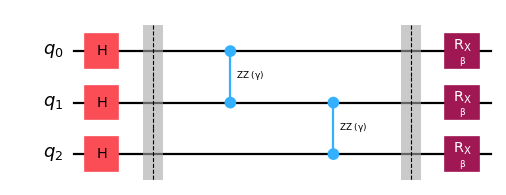


--- Running Scenario: Scenario A: Naive (3-Qubit Line (Sparse)) ---


TypeError: plot_tree() got an unexpected keyword argument 'neato_layout'

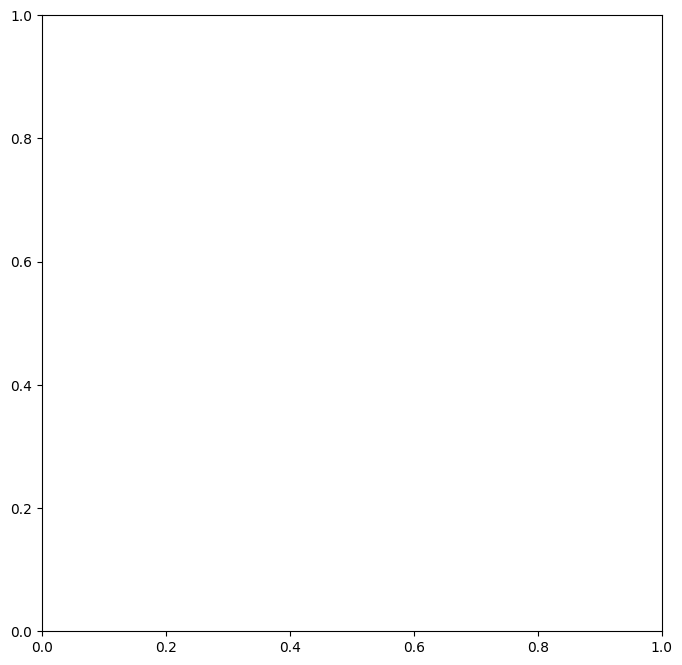

In [48]:
import matplotlib.pyplot as plt
import networkx as nx
import math
import warnings
# Suppress some annoying matplotlib warnings related to cotengra's plotting
warnings.filterwarnings("ignore", category=UserWarning)

# --- QISKIT IMPORTS ---
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

# --- TENSOR NETWORK IMPORTS ---
import quimb.tensor as qtn
import cotengra as ctg

# ==========================================
# CONFIGURATION
# ==========================================
# To demonstrate slicing on small circuits, we need a VERY tight memory limit.
# We will set the limit to 2^10 complex numbers (about 16 KB).
# This forces the optimizer to slice the 5-qubit dense circuit.
UPMEM_LIMIT_LOG2 = 10 

# ==========================================
# HELPER FUNCTION 1: Draw Qiskit Circuit
# ==========================================
def draw_qiskit_qaoa(G, name):
    """Draws the circuit using Qiskit's matplotlib engine."""
    print(f"\n{'='*60}\nANALYZING CIRCUIT: {name}\n{'='*60}")
    n = len(G.nodes)
    qc = QuantumCircuit(n)
    
    # 1. Initial State (+ layer)
    qc.h(range(n))
    qc.barrier()
    
    # 2. Cost Hamiltonian (ZZ interactions)
    gamma = Parameter('γ')
    for u, v in G.edges:
        # Add RZZ between connected nodes
        qc.rzz(gamma, u, v)
    qc.barrier()
    
    # 3. Mixer Hamiltonian (X rotations)
    beta = Parameter('β')
    qc.rx(beta, range(n))
    
    print(f"[1] Qiskit Logical Circuit Diagram ({name})")
    # Use display() if in Jupyter/Colab, otherwise print()
    try:
        display(qc.draw('mpl', style='iqp', scale=0.8))
    except:
        print("Matplotlib display not found, printing text version:")
        print(qc.draw())

# ==========================================
# HELPER FUNCTION 2: Run & Plot TN Scenario
# ==========================================
def run_tn_scenario(tn, optimizer, scenario_name, figsize=(8, 8)):
    print(f"\n--- Running Scenario: {scenario_name} ---")
    
    # 1. Optimize
    inputs = [tuple(t.inds) for t in tn]
    output = tuple(tn.outer_inds())
    size_dict = {i: d for i, d in tn.ind_sizes().items()}

    try:
        tree = optimizer.search(inputs, output, size_dict)
    except Exception as e:
        print(f"Optimizer Failed: {e}")
        return

    # 2. Stats
    max_size_log2 = math.log2(tree.max_size())
    flops_log10 = math.log10(tree.total_flops())
    slices = tree.nslices

    # 3. VISUALIZATION (THE FIX)
    fig, ax = plt.subplots(figsize=figsize)
    
    # We use 'plot_tent' for the tree structure OR 'plot_contig' for the graph
    # But to see the graph shape best, we pass a specific layout to plot_ring
    # 'kamada_kawai': Good for separating clusters
    # 'spring': Good for showing physical connectivity
    
    # Let's try to draw the 'Hypergraph' view which is usually more distinct
    # coloring by 'centrality' helps highlight the "busy" tensors
    tree.plot_ring(
        ax=ax, 
        neato_layout=True,  # This tries to un-clutter the nodes
        node_scale=20, 
        edge_alpha=0.5
    )
    
    title_text = (f"{scenario_name}\n"
                  f"MaxMem: 2^{max_size_log2:.1f} | Slices: {slices}")
    ax.set_title(title_text)
    plt.show()

def run_tn_scenario_1(tn, optimizer, scenario_name, figsize=(6,6)):
    """
    Takes a TN and an optimizer configuration, finds the path,
    and plots the 'Ring View' showing memory usage and cuts.
    """
    print(f"\n--- Running Scenario: {scenario_name} ---")
    
    # Extract TN structure for Cotengra
    inputs = [tuple(t.inds) for t in tn]
    output = tuple(tn.outer_inds())
    size_dict = {i: d for i, d in tn.ind_sizes().items()}

    # Run the optimization search
    try:
        tree = optimizer.search(inputs, output, size_dict)
    except Exception as e:
        print(f"Optimizer Failed: {e}")
        return

    # Gather stats
    max_size_log2 = math.log2(tree.max_size())
    flops_log10 = math.log10(tree.total_flops())
    slices = tree.nslices
    
    print(f"Results for {scenario_name}:")
    print(f"  -> Max Intermediate Tensor: 2^{max_size_log2:.1f}")
    print(f"  -> Total Complexity: 10^{flops_log10:.1f} FLOPS")
    print(f"  -> Parallel Slices Needed: {slices}")

    # --- THE FIX IS HERE ---
    plt.close()
    # 1. Create the Figure and Axes explicitly
    fig, ax = plt.subplots(figsize=figsize)
    
    # 2. Pass the 'ax' to plot_ring so it draws on YOUR canvas
    tree.plot_ring(ax=ax)
    
    # 3. Set the title on the Axes, not the generic plt
    title_text = (f"{scenario_name}\n"
                  f"MaxMem: 2^{max_size_log2:.1f} | Slices: {slices}")
    ax.set_title(title_text)
    
    plt.show()

# ==========================================
# MAIN ANALYSIS LOOP
# ==========================================

# DEFINE THE CIRCUITS
circuits = [
    # Circuit A: Very Simple
    (nx.path_graph(3), "3-Qubit Line (Sparse)"),
    # Circuit B: Small but Dense (Harder)
    (nx.complete_graph(5), "5-Qubit Complete (Dense)"),
    # Circuit C: Larger but Dense (Harder)
    (nx.complete_graph(8), "5-Qubit Complete (Dense)")
]

# DEFINE THE OPTIMIZERS

# 1. Naive (Greedy)
opt_naive = ctg.HyperOptimizer(
    methods=['greedy'], max_repeats=1, progbar=False)

# 2. CPU Optimized (High Quality, No fixed limit)
# We allow it to find the natural "tree width" of the problem.
opt_cpu = ctg.HyperOptimizer(
    max_repeats=32, progbar=False)

# 3. UPMEM Optimized (High Quality + Strict Slicing Limit)
# We force intermediate tensors to be very small (2^10 elements)
opt_upmem = ctg.HyperOptimizer(
    max_repeats=32, progbar=False,
    slicing_opts={'target_size': 2**UPMEM_LIMIT_LOG2}
)


# RUN LOOP
for G, name in circuits:
    # 1. Visualize Qiskit Circuit
    draw_qiskit_qaoa(G, name)
    
    # 2. Create Quimb Tensor Network counterpart
    # Ensure parameters match the Qiskit conceptual ones
    terms = {edge: 1.0 for edge in G.edges}
    circ_quimb = qtn.circ_qaoa(terms, depth=1, gammas=[0.1], betas=[0.1])
    tn = circ_quimb.psi

    # 3. Run the three scenarios
    run_tn_scenario(tn, opt_naive, f"Scenario A: Naive ({name})")
    run_tn_scenario(tn, opt_cpu,   f"Scenario B: CPU Opt ({name})")
    run_tn_scenario(tn, opt_upmem, f"Scenario C: UPMEM Sliced ({name})")
    print("\n" + "-"*60)


ANALYZING: 8-Qubit Line

[1] Logical Circuit: 8-Qubit Line
      ┌───┐ ░                                                                                                         »
 q_0: ┤ H ├─░──■──────────────────────────────────────────────────────────────────────────────────────────────────────»
      ├───┤ ░  │ZZ(γ)                                                                                                 »
 q_1: ┤ H ├─░──■───────■──────────────────────────────────────────────────────────────────────────────────────────────»
      ├───┤ ░          │ZZ(γ)                                                                                         »
 q_2: ┤ H ├─░──────────■───────■──────────────────────────────────────────────────────────────────────────────────────»
      ├───┤ ░                  │ZZ(γ)                                                                                 »
 q_3: ┤ H ├─░──────────────────■───────■────────────────────────────────────────────────────────────

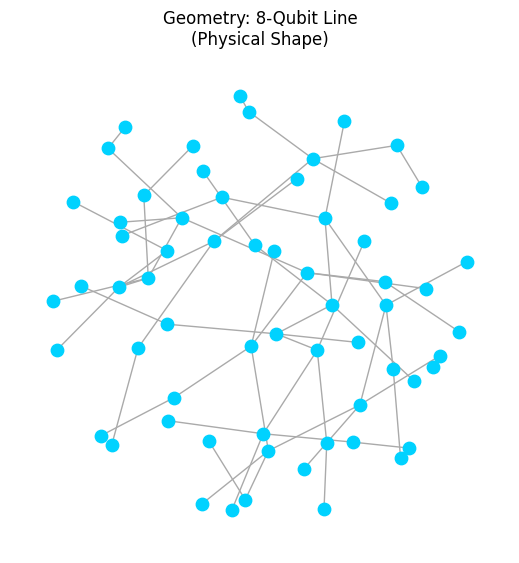

Running Naive Path...


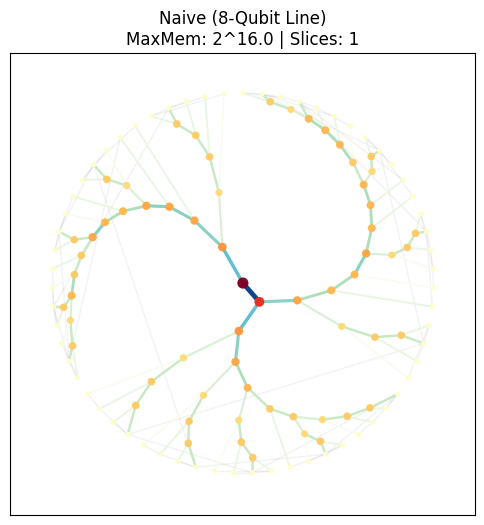

Running UPMEM Sliced Path...


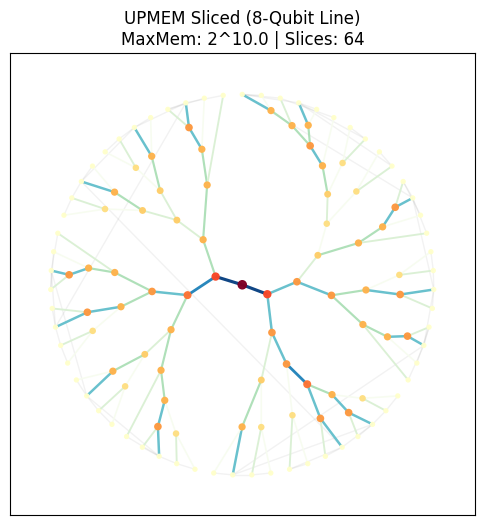


ANALYZING: 8-Qubit Complete

[1] Logical Circuit: 8-Qubit Complete
      ┌───┐ ░                                                                                                         »
 q_0: ┤ H ├─░──■───────■───────■───────────────■───────────────■───────────────────────■───────────────────────■──────»
      ├───┤ ░  │ZZ(γ)  │       │               │               │                       │                       │      »
 q_1: ┤ H ├─░──■───────┼───────┼───────■───────┼───────■───────┼───────■───────────────┼───────■───────────────┼──────»
      ├───┤ ░          │ZZ(γ)  │       │ZZ(γ)  │       │       │       │               │       │               │      »
 q_2: ┤ H ├─░──────────■───────┼───────■───────┼───────┼───────┼───────┼───────■───────┼───────┼───────■───────┼──────»
      ├───┤ ░                  │ZZ(γ)          │       │ZZ(γ)  │       │       │ZZ(γ)  │       │       │       │      »
 q_3: ┤ H ├─░──────────────────■───────────────┼───────■───────┼───────┼───────■───────┼────

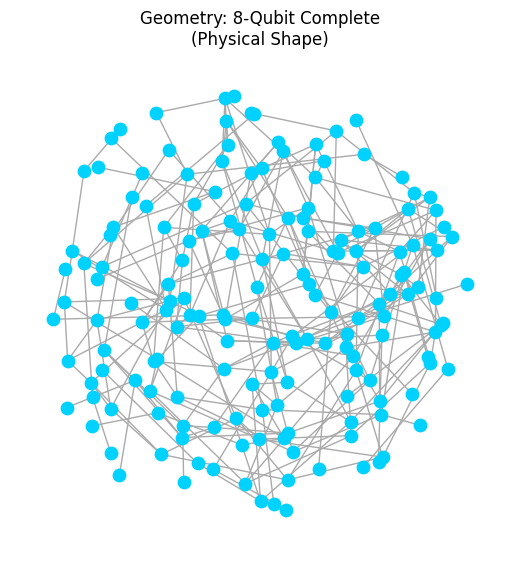

Running Naive Path...


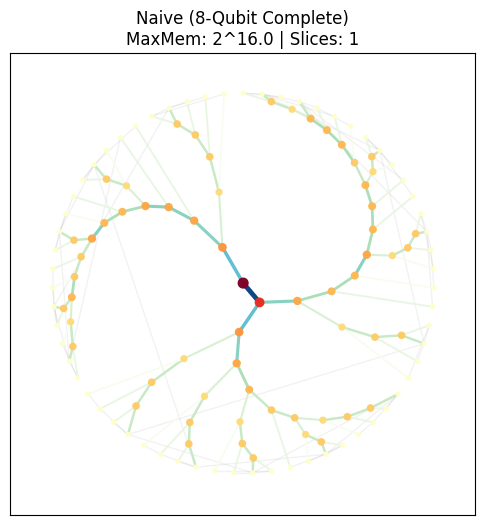

Running UPMEM Sliced Path...


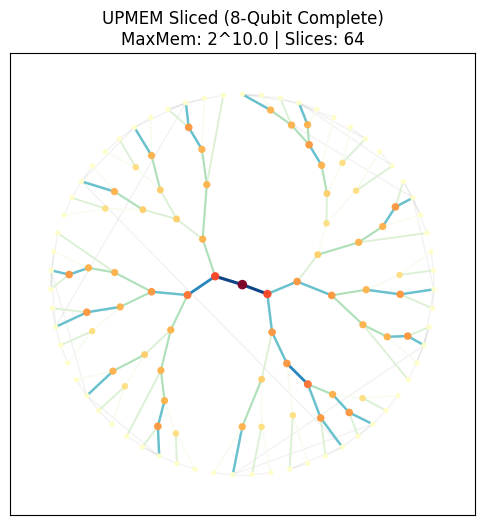

In [51]:
import matplotlib.pyplot as plt
import networkx as nx
import math
import warnings
import quimb.tensor as qtn
import cotengra as ctg

# Qiskit imports
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit import Parameter

# Suppress warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. HELPER: Qiskit Circuit Visualization
# ==========================================
def draw_qiskit_circuit(G, title):
    """Draws the logical quantum circuit"""
    n = len(G.nodes)
    qc = QuantumCircuit(n)
    
    # 1. Init
    qc.h(range(n))
    qc.barrier()
    
    # 2. Interactions (Cost Hamiltonian)
    gamma = Parameter('γ')
    for u, v in G.edges:
        qc.rzz(gamma, u, v)
    qc.barrier()
    
    # 3. Mixer
    beta = Parameter('β')
    qc.rx(beta, range(n))

    print(f"\n[1] Logical Circuit: {title}")
    # Draw text-based to avoid any Matplotlib backend issues
    print(qc.draw(fold=120))

# ==========================================
# 2. HELPER: True Geometry Visualization
# ==========================================
def visualize_geometry(tn, title):
    """
    Draws the Tensor Network using 'Spring Layout' physics.
    Line Graph -> Snake. Complete Graph -> Ball.
    """
    G = nx.Graph()
    # Add nodes
    for i in range(tn.num_tensors):
        G.add_node(i)
    
    # Add edges if tensors share indices
    tensors = [t for t in tn]
    for i in range(len(tensors)):
        for j in range(i + 1, len(tensors)):
            if set(tensors[i].inds).intersection(tensors[j].inds):
                G.add_edge(i, j)
    
    # Create Layout
    plt.figure(figsize=(5, 5))
    pos = nx.spring_layout(G, seed=42, k=0.5, iterations=50)
    
    nx.draw(G, pos, 
            node_size=80, 
            node_color='#00d2ff', 
            edge_color='#aaaaaa', 
            width=1.0)
    
    plt.title(f"Geometry: {title}\n(Physical Shape)")
    plt.show()

# ==========================================
# 3. HELPER: Contraction Scenario
# ==========================================
def run_tn_scenario(tn, optimizer, scenario_name):
    # Setup
    inputs = [tuple(t.inds) for t in tn]
    output = tuple(tn.outer_inds())
    size_dict = {i: d for i, d in tn.ind_sizes().items()}

    # Optimize
    try:
        tree = optimizer.search(inputs, output, size_dict)
    except Exception as e:
        print(f"Optimizer Failed: {e}")
        return

    # Stats
    max_size_log2 = math.log2(tree.max_size())
    slices = tree.nslices

    # Plot
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # --- SAFE PLOT COMMAND ---
    # We pass ONLY 'ax'. No styling args that crash different versions.
    tree.plot_ring(ax=ax)
    
    ax.set_title(f"{scenario_name}\nMaxMem: 2^{max_size_log2:.1f} | Slices: {slices}")
    plt.show()

# ==========================================
# 4. MAIN EXECUTION
# ==========================================

# Define Circuits
circuits = [
    (nx.path_graph(16), "8-Qubit Line"),      
    (nx.complete_graph(16), "8-Qubit Complete") 
]

# Define Optimizers
opt_naive = ctg.HyperOptimizer(methods=['greedy'], max_repeats=1, progbar=False)

# UPMEM: Force strict limit of 2^10 elements (~16KB)
opt_upmem = ctg.HyperOptimizer(
    max_repeats=16, progbar=False,
    slicing_opts={'target_size': 2**10} 
)

for G, name in circuits:
    print(f"\n{'='*60}\nANALYZING: {name}\n{'='*60}")
    
    # 1. Qiskit View
    draw_qiskit_circuit(G, name)
    
    # Setup TN
    terms = {edge: 1.0 for edge in G.edges}
    circ_quimb = qtn.circ_qaoa(terms, depth=1, gammas=[0.1], betas=[0.1])
    tn = circ_quimb.psi

    # 2. Geometry View
    visualize_geometry(tn, name)
    
    # 3. Naive Path
    print("Running Naive Path...")
    run_tn_scenario(tn, opt_naive, f"Naive ({name})")
    
    # 4. UPMEM Path
    print("Running UPMEM Sliced Path...")
    run_tn_scenario(tn, opt_upmem, f"UPMEM Sliced ({name})")